# Example 8: ABC Calibration with CalibrationContext [(GitHub link)](https://github.com/heberlr/UQ_PhysiCell/tree/main/examples/virus-mac-new/ex8_ABC_Calib.ipynb)

This notebook demonstrates how to perform Approximate Bayesian Computation (ABC) for model calibration using the [virus-mac-new](https://github.com/heberlr/UQ_PhysiCell//tree/main/examples/virus-mac-new) PhysiCell model. ABC is a powerful technique for parameter estimation when the likelihood function is intractable, making it ideal for calibrating complex computational models against experimental or observational data.

The calibration process uses ABC-SMC (Sequential Monte Carlo) to estimate posterior distributions of model parameters by:

1. **Prior distributions**: Initial beliefs about parameter values
2. **Distance functions**: To measure discrepancy between model predictions and observed data
3. **Sequential Monte Carlo**: To iteratively refine parameter estimates
4. **Adaptive tolerance**: To progressively improve approximation quality

The observational data represents the "ground truth" generated from a single simulation with known parameter values:
- **mac_phag_rate_infected**: 1.0 (rate at which macrophages phagocytose infected epithelial cells)
- **epi2infected_hfm**: 0.4 (half-maximum rate for epithelial cell infection transition)

For this example, we focus on these **2 key parameters** to demonstrate the ABC calibration workflow. The *in silico* observational data uses the same data as Example 7.

## Import modules and set up parameters

In [1]:
from uq_physicell.abc import CalibrationContext, run_abc_calibration
from pyabc import RV, Distribution, visualization
import logging
import numpy as np
import matplotlib.pyplot as plt

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Real values for obs. data (focusing on 2 parameters)
dic_real_value = {'mac_phag_rate_infected': 1.0, 'epi2infected_hfm': 0.4}

# File name
db_path = "ex8_ABC_Calib.db"
obs_data_path = "ex7_ObsData.csv"  # Using same observational data as ex7

# Model configuration
model_config = {
    "ini_path": "uq_pc_struc.ini", 
    "struc_name": "Model_struc_Calib", 
}

# Quantities of Interest (QoI) functions
qoi_functions = {
    "epi_": lambda df: len(df[df['cell_type'] == 'epithelial']), 
    "epi_infected": lambda df: len(df[df['cell_type'] == 'epithelial_infected'])
}

# Mapping of QoI names to observed data columns
obs_data_columns = {
    'time': "Time", 
    "epi_": "Healthy Epithelial Cells", 
    "epi_infected": "Infected Epithelial Cells"
}

## Configuration Setup

Define all the configuration parameters needed for ABC-SMC calibration.

In [2]:
def euclidean_distance_epi(data1, data2):
    """Simple distance function for epi_ QoI"""
    try:
        obs_vals = np.array(data1['epi_'])
        sim_vals = np.array(data2['epi_'])
        
        return np.sum((obs_vals - sim_vals)**2)
    except:
        return float('inf')

def euclidean_distance_epi_infected(data1, data2):
    """Simple distance function for epi_infected QoI"""
    try:
        obs_vals = np.array(data1['epi_infected'])
        sim_vals = np.array(data2['epi_infected'])
        return np.sum((obs_vals - sim_vals)**2)
    except:
        return float('inf')

# Distance functions for ABC (these would be the actual distance functions used in ABC)
distance_functions = {
    "epi_": {"function": euclidean_distance_epi},
    "epi_infected": {"function": euclidean_distance_epi_infected}
}

# Define prior distributions using pyABC (based on search space bounds)
prior = Distribution(
    mac_phag_rate_infected=RV("uniform", 0.7, 0.8),  # uniform between 0.7 and 1.5 (0.7 + 0.8)
    epi2infected_hfm=RV("uniform", 0.1, 0.4)        # uniform between 0.1 and 0.5 (0.1 + 0.4)
)

# ABC options (configured for demonstration)
abc_options = {
    'max_populations': 2,           # Number of ABC-SMC populations
    'max_simulations': 100,         # Maximum total simulations
    'population_strategy': 'adaptive', # Adaptive population size strategy between min and max population sizes
    'min_population_size': 10,      # Minimum particles per population
    'max_population_size': 50,     # Maximum particles per population
    'adaptive_distance': True,
    'sampler': 'multicore',
    'num_workers': 6,
}

print("✅ Configuration setup complete")
print(f"📊 Real values: {dic_real_value}")

✅ Configuration setup complete
📊 Real values: {'mac_phag_rate_infected': 1.0, 'epi2infected_hfm': 0.4}


## Create CalibrationContext

Initialize the CalibrationContext with all the configuration parameters.

In [3]:
# Create the calibration context
calib_context = CalibrationContext(
    db_path=db_path,
    obsData=obs_data_path,  # Using CSV file path like ex7
    obsData_columns=obs_data_columns,
    model_config=model_config,
    qoi_functions=qoi_functions,
    distance_functions=distance_functions,
    prior=prior,
    abc_options=abc_options,
    logger=logger
)

print("✅ CalibrationContext created successfully")
print(f"📁 Database: {calib_context.db_path}")
print(f"🎯 QoIs: {list(calib_context.qoi_functions.keys())}")
print(f"🔍 Parameters: {list(calib_context.prior.keys())}")
print(f"⚙️ Sampler: {calib_context.sampler_type} with {calib_context.num_workers} workers")

✅ CalibrationContext created successfully
📁 Database: ex8_ABC_Calib.db
🎯 QoIs: ['epi_', 'epi_infected']
🔍 Parameters: ['mac_phag_rate_infected', 'epi2infected_hfm']
⚙️ Sampler: multicore with 6 workers


In [4]:
# Run the ABC-SMC calibration with real PhysiCell model
print("🚀 Starting ABC-SMC calibration with PhysiCell model...")
print(f"🎯 Target parameters: {dic_real_value}")
print(f"📊 Max populations: {calib_context.max_populations}")
print(f"🔬 Max simulations: {calib_context.max_simulations}")

# You can uncomment the following code when you have a working PhysiCell setup
try:
    history = run_abc_calibration(calib_context=calib_context)
    
    print("🎉 ABC-SMC calibration completed successfully!")
    print(f"📊 Final populations: {history.n_populations}")
    print(f"🔬 Total simulations: {history.total_nr_simulations}")
    
except Exception as e:
    print(f"❌ Calibration failed: {e}")
    import traceback
    traceback.print_exc()

ABC.Sampler INFO: Parallelize sampling on 1 processes.
INFO:ABC.Sampler:Parallelize sampling on 1 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-02-13 12:30:47>
INFO:ABC.History:Start <ABCSMC id=1, start_time=2026-02-13 12:30:47>
ABC INFO: Calibration sample t = -1.
INFO:ABC:Calibration sample t = -1.


🚀 Starting ABC-SMC calibration with PhysiCell model...
🎯 Target parameters: {'mac_phag_rate_infected': 1.0, 'epi2infected_hfm': 0.4}
📊 Max populations: 2
🔬 Max simulations: 100


ABC.Population INFO: Recording also rejected particles: True
INFO:ABC.Population:Recording also rejected particles: True
ABC INFO: t: 0, eps: 1.00114158e+00.
INFO:ABC:t: 0, eps: 1.00114158e+00.
ABC INFO: Accepted: 50 / 108 = 4.6296e-01, ESS: 5.0000e+01.
INFO:ABC:Accepted: 50 / 108 = 4.6296e-01, ESS: 5.0000e+01.
ABC.Adaptation INFO: Change nr particles 50 -> 50
INFO:ABC.Adaptation:Change nr particles 50 -> 50
ABC INFO: Stop: Total simulations budget.
INFO:ABC:Stop: Total simulations budget.
ABC.History INFO: Done <ABCSMC id=1, duration=2:05:36.848631, end_time=2026-02-13 14:36:24>
INFO:ABC.History:Done <ABCSMC id=1, duration=2:05:36.848631, end_time=2026-02-13 14:36:24>


🎉 ABC-SMC calibration completed successfully!
📊 Final populations: 1
🔬 Total simulations: 158


## Analysis of Results

After calibration, you can analyze the results using pyABC's built-in tools.


📈 ABC-SMC Evolution:
   Total populations: 1
   Total simulations: 158


name,epi2infected_hfm,mac_phag_rate_infected
id,,
2,0.346153,1.159550
3,0.354043,0.920385
4,0.401899,1.447023
5,0.451707,1.355795
6,0.366163,0.875740



🎯 Parameter Recovery Analysis:
   mac_phag_rate_infected:
     True value: 1.000
     Posterior mean: 1.132 ± 0.220
     Relative error: 13.2%
   epi2infected_hfm:
     True value: 0.400
     Posterior mean: 0.401 ± 0.057
     Relative error: 0.2%


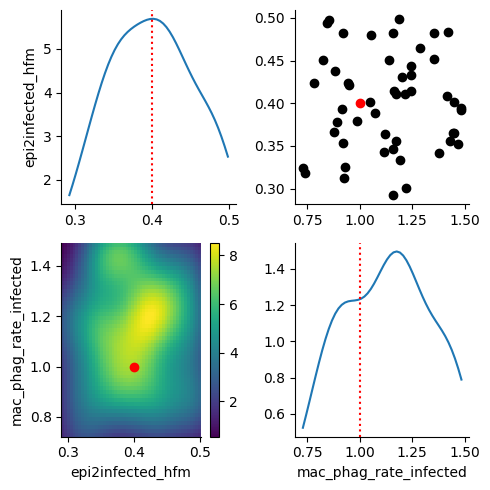

In [5]:
# Analysis of Results (run this cell after successful calibration)
try:
    # Evolution of populations
    print(f"\n📈 ABC-SMC Evolution:")
    print(f"   Total populations: {history.n_populations}")
    print(f"   Total simulations: {history.total_nr_simulations}")
    
    # Plot population evolution if multiple populations
    if history.n_populations > 1:
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
        visualization.plot_epsilons(history, yscale='linear', ax=ax)
        
    # Get the posterior samples from the last population
    df_posterior, w = history.get_distribution(m=0, t=history.max_t)
    display(df_posterior.head())
    # Compare with true values
    print(f"\n🎯 Parameter Recovery Analysis:")
    for param in dic_real_value.keys():
        true_val = dic_real_value[param]
        posterior_mean = df_posterior[param].mean()
        posterior_std = df_posterior[param].std()
        print(f"   {param}:")
        print(f"     True value: {true_val:.3f}")
        print(f"     Posterior mean: {posterior_mean:.3f} ± {posterior_std:.3f}")
        print(f"     Relative error: {abs(posterior_mean - true_val) / true_val * 100:.1f}%")
    
    # Plot posterior distributions
    visualization.plot_kde_matrix(df_posterior, w, refval=dic_real_value, refval_color="red")
        
except NameError:
    print("📈 Run the calibration first to analyze results")
except Exception as e:
    print(f"❌ Analysis failed: {e}")